# 02 — Validate AIFS ENS v2 heat-hazard forecasts

First-pass validation of structure, valid dates, probability fields, ERA5 alignment, RMSE, and Brier score.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs

xr.set_options(keep_attrs=True)

In [2]:
AIFS_MONTHLY_ROOT = Path('/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly')
ERA5_ROOT = Path('/net/monsoon/kylehall/ERA5/heat_extremes_climatology')
YEAR, MONTH = 2024, 7
INIT_INDEX = 0
PLOT_FORECAST_DAYS = (0, 5, 10)

AIFS_STORE = AIFS_MONTHLY_ROOT / str(YEAR) / f'aifs_ens_v2_heat_{YEAR}{MONTH:02d}.zarr'
ERA5_DAILY_STORE = ERA5_ROOT / 'daily' / 't2m_daily_mean.zarr'
ERA5_HAZARD_STORE = ERA5_ROOT / 'hazards' / 't2m_daily_mean_q95_hazards.zarr'
FIGURE_DIR = AIFS_MONTHLY_ROOT.parent / 'validation_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(AIFS_STORE)

/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2024/aifs_ens_v2_heat_202407.zarr


In [9]:
def area_weighted_mean(da):
    w = np.cos(np.deg2rad(da.latitude))
    return da.weighted(w).mean(('latitude','longitude'))

def normalize_longitude_like(source, target_longitude):
    use360 = float(target_longitude.min()) >= 0 and float(target_longitude.max()) > 180
    lon = source.longitude % 360 if use360 else ((source.longitude + 180) % 360) - 180
    return source.assign_coords(longitude=lon).sortby('longitude')

def map_to_forecast_grid(source, forecast, method):
    source = normalize_longitude_like(source, forecast.longitude)
    if (np.array_equal(source.latitude.values, forecast.latitude.values) and
        np.array_equal(source.longitude.values, forecast.longitude.values)):
        return source
    return source.interp(latitude=forecast.latitude, longitude=forecast.longitude, method=method)

def match_era5_by_valid_date(
    observation: xr.DataArray,
    valid_date: xr.DataArray,
) -> xr.DataArray:
    """
    Match ERA5 daily observations to forecast local valid dates.

    Parameters
    ----------
    observation
        ERA5 field with dimensions:
        time, latitude, longitude

    valid_date
        Forecast valid dates with dimensions:
        time, forecast_day, longitude

    Returns
    -------
    xr.DataArray
        ERA5 values with dimensions:
        time, forecast_day, latitude, longitude
    """
    required_observation_dims = {
        "time",
        "latitude",
        "longitude",
    }
    required_valid_date_dims = {
        "time",
        "forecast_day",
        "longitude",
    }

    missing_observation_dims = (
        required_observation_dims - set(observation.dims)
    )
    if missing_observation_dims:
        raise ValueError(
            "Observation is missing dimensions: "
            f"{sorted(missing_observation_dims)}"
        )

    missing_valid_date_dims = (
        required_valid_date_dims - set(valid_date.dims)
    )
    if missing_valid_date_dims:
        raise ValueError(
            "valid_date is missing dimensions: "
            f"{sorted(missing_valid_date_dims)}"
        )

    # Avoid using "time" simultaneously as the ERA5 lookup dimension
    # and the forecast-initialization dimension.
    observation = observation.rename(
        {"time": "era5_time"}
    )
    valid_date = valid_date.rename(
        {"time": "initialization"}
    )

    # Vectorized indexing:
    # era5_time varies over initialization, forecast_day, and longitude.
    matched = observation.sel(
        era5_time=valid_date,
        longitude=valid_date["longitude"],
    )

    matched = matched.rename(
        {"initialization": "time"}
    )

    return matched.transpose(
        "time",
        "forecast_day",
        "latitude",
        "longitude",
    )


def plot_global(field, title, label, vmin=None, vmax=None, filename=None):
    fig=plt.figure(figsize=(12,4.8)); ax=plt.axes(projection=ccrs.PlateCarree())
    field.plot(ax=ax, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cbar_kwargs={'label':label})
    ax.coastlines(); ax.set_title(title)
    if filename: fig.savefig(FIGURE_DIR/filename, dpi=180, bbox_inches='tight')
    plt.show()

## 1. Open one monthly store

In [4]:
aifs = xr.open_zarr(AIFS_STORE, consolidated=False, chunks={})
print(aifs)

<xarray.Dataset> Size: 2GB
Dimensions:                            (time: 8, forecast_day: 14,
                                        latitude: 721, longitude: 1440)
Coordinates:
  * time                               (time) datetime64[ns] 64B 2024-07-01 ....
  * forecast_day                       (forecast_day) int16 28B 0 1 2 ... 12 13
  * latitude                           (latitude) float64 6kB 90.0 ... -90.0
  * longitude                          (longitude) float64 12kB 0.0 ... 359.8
    valid_date                         (time, forecast_day, longitude) datetime64[ns] 1MB dask.array<chunksize=(1, 8, 180), meta=np.ndarray>
    dayofyear                          (time, forecast_day, longitude) int64 1MB dask.array<chunksize=(1, 8, 180), meta=np.ndarray>
    local_solar_offset_hours           (longitude) float64 12kB dask.array<chunksize=(180,), meta=np.ndarray>
Data variables:
    t2m_daily_mean_ensemble_mean       (time, forecast_day, latitude, longitude) float32 465MB dask.array<

## 2. Structural and valid-date checks

In [5]:
expected={'t2m_daily_mean_ensemble_mean','hot_day_q95_probability','heatwave_start_q95_2d_probability','heatwave_start_q95_3d_probability'}
assert not expected.difference(aifs.data_vars), expected.difference(aifs.data_vars)
for name in expected - {'t2m_daily_mean_ensemble_mean'}:
    lo=float(aifs[name].min(skipna=True).compute()); hi=float(aifs[name].max(skipna=True).compute())
    assert 0 <= lo <= hi <= 1, (name,lo,hi)
inc=np.unique(aifs.valid_date.diff('forecast_day').values.astype('timedelta64[D]'))
print('valid-date increments:',inc)
assert np.all(inc == np.timedelta64(1,'D'))
print('Structural checks passed.')

valid-date increments: [1]
Structural checks passed.


In [6]:
init=aifs.isel(time=INIT_INDEX)
print('Initialization:',init.time.values)
for lon in [float(aifs.longitude.values[i]) for i in (0,len(aifs.longitude)//4,len(aifs.longitude)//2,-1)]:
    print(lon, init.valid_date.sel(longitude=lon, method='nearest').values[:6])

Initialization: 2024-07-01T00:00:00.000000000
0.0 ['2024-07-02T00:00:00.000000000' '2024-07-03T00:00:00.000000000'
 '2024-07-04T00:00:00.000000000' '2024-07-05T00:00:00.000000000'
 '2024-07-06T00:00:00.000000000' '2024-07-07T00:00:00.000000000']
90.0 ['2024-07-02T00:00:00.000000000' '2024-07-03T00:00:00.000000000'
 '2024-07-04T00:00:00.000000000' '2024-07-05T00:00:00.000000000'
 '2024-07-06T00:00:00.000000000' '2024-07-07T00:00:00.000000000']
180.0 ['2024-07-01T00:00:00.000000000' '2024-07-02T00:00:00.000000000'
 '2024-07-03T00:00:00.000000000' '2024-07-04T00:00:00.000000000'
 '2024-07-05T00:00:00.000000000' '2024-07-06T00:00:00.000000000']
359.75 ['2024-07-02T00:00:00.000000000' '2024-07-03T00:00:00.000000000'
 '2024-07-04T00:00:00.000000000' '2024-07-05T00:00:00.000000000'
 '2024-07-06T00:00:00.000000000' '2024-07-07T00:00:00.000000000']


## 3. Temperature and probability maps

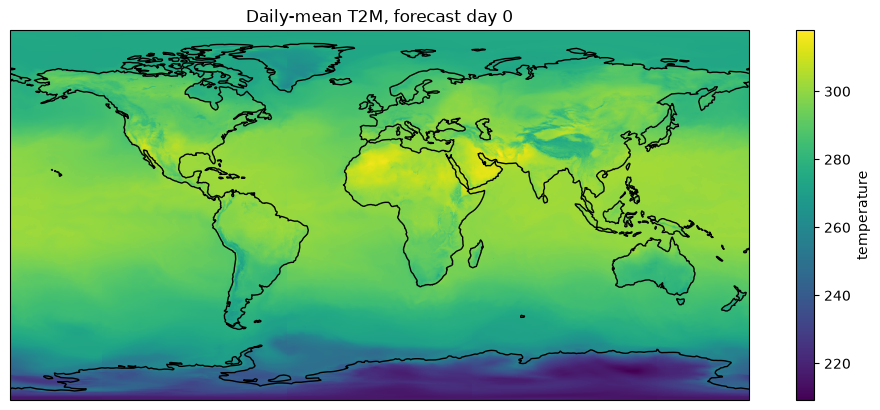

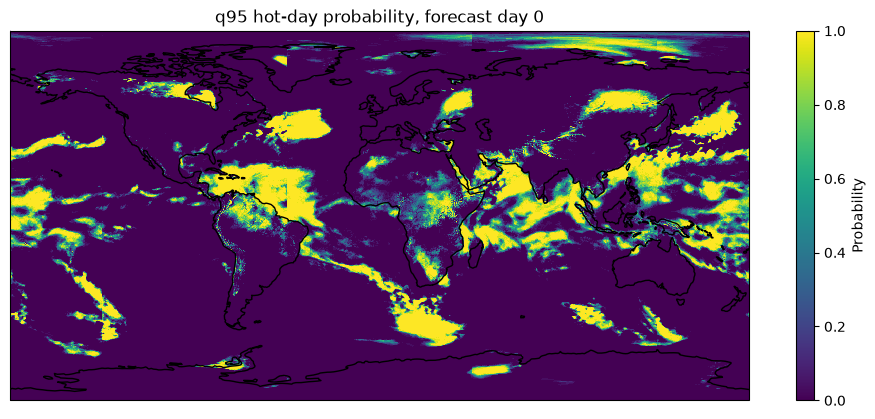

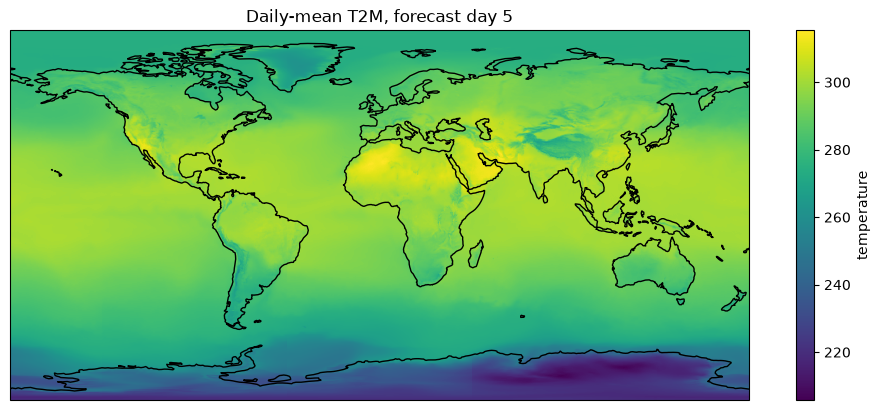

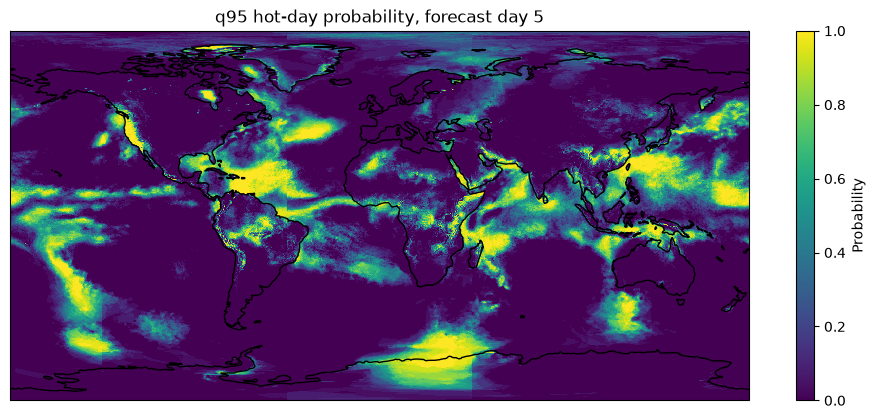

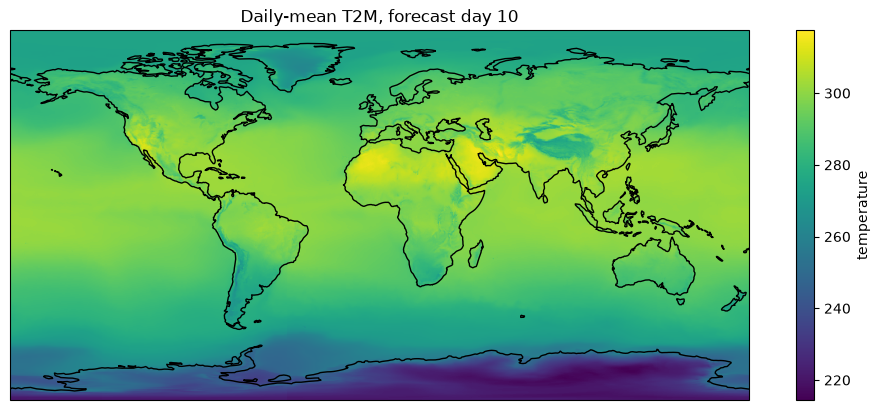

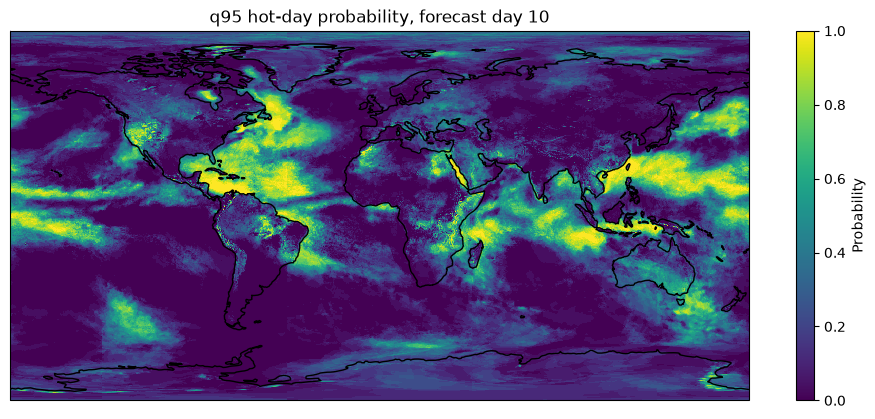

In [7]:
temp=aifs.t2m_daily_mean_ensemble_mean
prob=aifs.hot_day_q95_probability
for day in PLOT_FORECAST_DAYS:
    if day not in temp.forecast_day: continue
    plot_global(temp.isel(time=INIT_INDEX).sel(forecast_day=day).compute(), f'Daily-mean T2M, forecast day {day}', temp.attrs.get('units','temperature'), filename=f'temp_{YEAR}{MONTH:02d}_d{day}.png')
    plot_global(prob.isel(time=INIT_INDEX).sel(forecast_day=day).compute(), f'q95 hot-day probability, forecast day {day}', 'Probability', 0, 1, f'prob_{YEAR}{MONTH:02d}_d{day}.png')

## 4. Open and match ERA5

In [10]:
era5_temp=xr.open_zarr(ERA5_DAILY_STORE, consolidated=True, chunks={})['t2m_daily_mean']
era5_hot=xr.open_zarr(ERA5_HAZARD_STORE, consolidated=True, chunks={})['hot_day_q95']
era5_temp=map_to_forecast_grid(era5_temp,temp,'linear')
era5_hot=map_to_forecast_grid(era5_hot.astype(np.float32),prob,'nearest') > 0.5

matched_temp = match_era5_by_valid_date(
    era5_temp,
    aifs.valid_date,
)

matched_hot = match_era5_by_valid_date(
    era5_hot,
    aifs.valid_date,
)

print(matched_temp)
print(matched_hot)
print("Forecast:", prob.sizes)
print("Matched ERA5:", matched_hot.sizes)

xr.align(
    prob,
    matched_hot,
    join="exact",
)

print("Forecast and ERA5 coordinates align exactly.")


<xarray.DataArray 't2m_daily_mean' (time: 8, forecast_day: 14, latitude: 721,
                                    longitude: 1440)> Size: 465MB
dask.array<transpose, shape=(8, 14, 721, 1440), dtype=float32, chunksize=(1, 14, 145, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time                      (time) datetime64[ns] 64B 2024-07-01 ... 2024-0...
  * forecast_day              (forecast_day) int16 28B 0 1 2 3 4 ... 10 11 12 13
  * latitude                  (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * longitude                 (longitude) float64 12kB 0.0 0.25 ... 359.5 359.8
    local_solar_offset_hours  (longitude) float64 12kB dask.array<chunksize=(1440,), meta=np.ndarray>
    era5_time                 (time, forecast_day, longitude) datetime64[ns] 1MB ...
    valid_date                (time, forecast_day, longitude) datetime64[ns] 1MB dask.array<chunksize=(1, 8, 180), meta=np.ndarray>
    dayofyear                 (time, forecast_day, longitude) int64 1MB dask.array<

## 5. Forecast versus ERA5 case maps

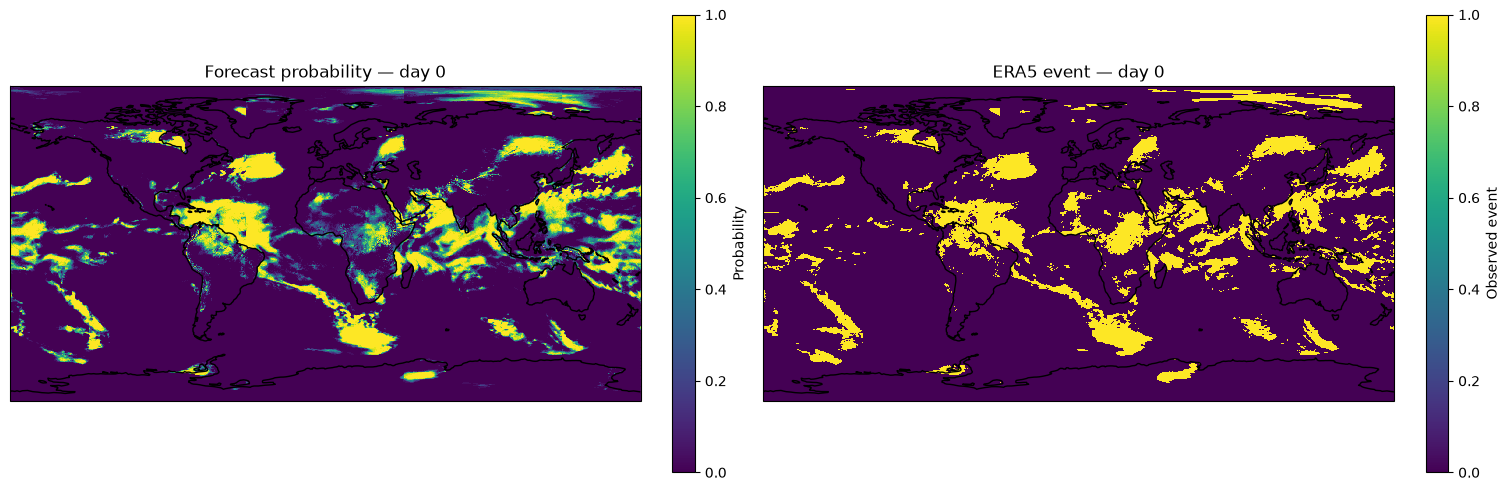

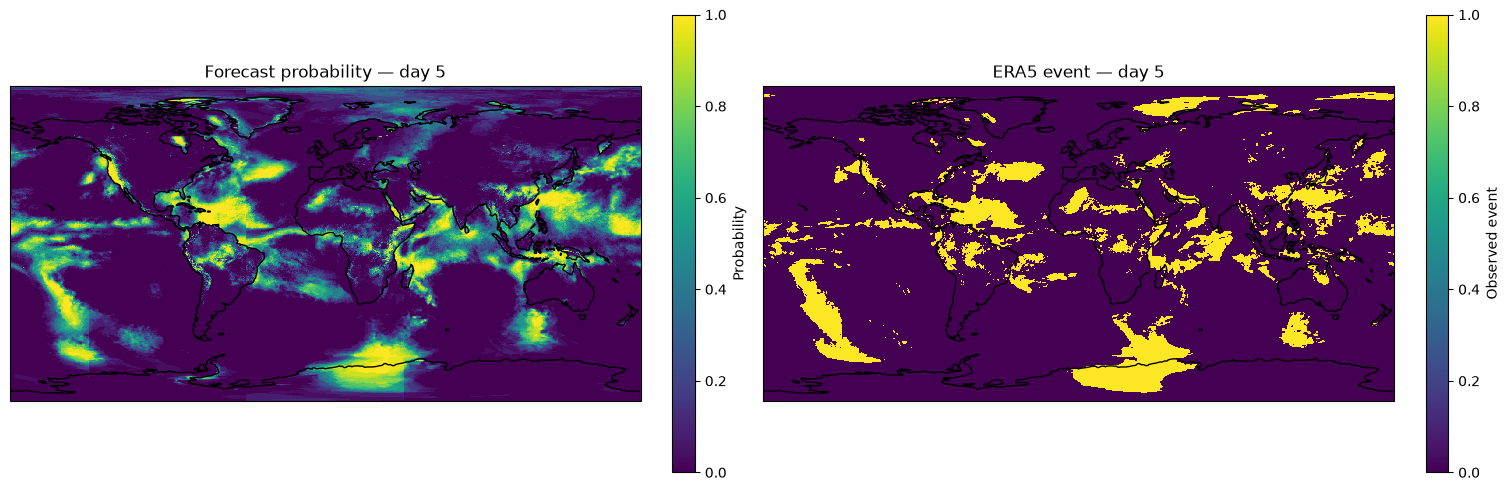

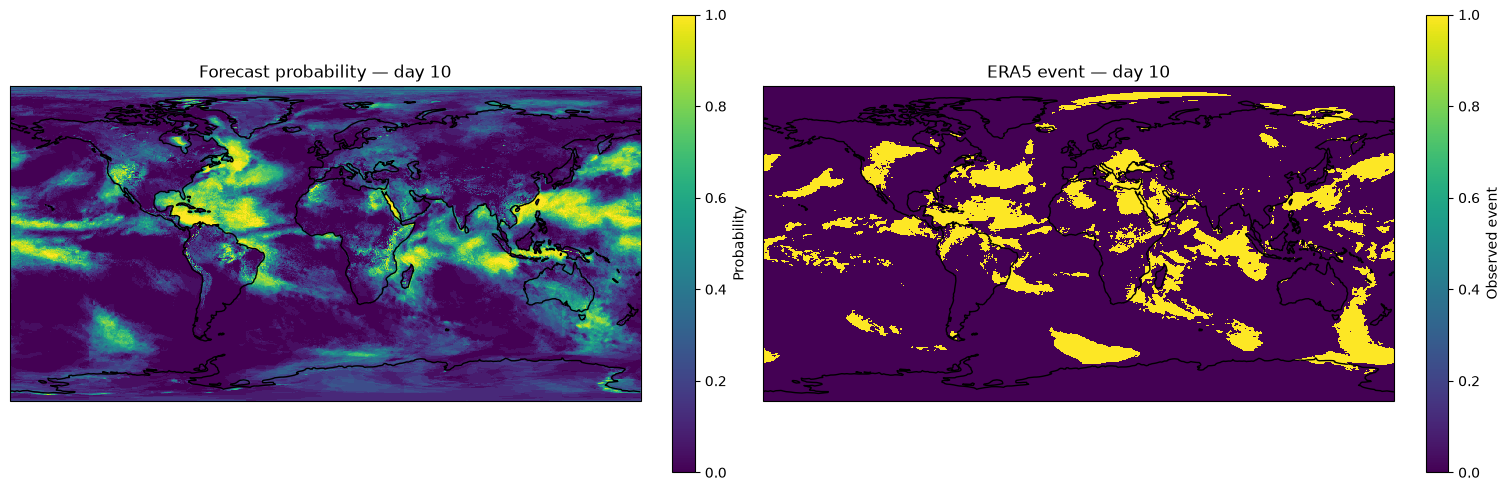

In [11]:
for day in PLOT_FORECAST_DAYS:
    if day not in prob.forecast_day: continue
    p=prob.isel(time=INIT_INDEX).sel(forecast_day=day).compute()
    y=matched_hot.isel(time=INIT_INDEX).sel(forecast_day=day).compute()
    fig,axes=plt.subplots(1,2,figsize=(15,4.8),subplot_kw={'projection':ccrs.PlateCarree()},constrained_layout=True)
    p.plot(ax=axes[0],transform=ccrs.PlateCarree(),vmin=0,vmax=1,cbar_kwargs={'label':'Probability'})
    y.astype(float).plot(ax=axes[1],transform=ccrs.PlateCarree(),vmin=0,vmax=1,cbar_kwargs={'label':'Observed event'})
    for ax in axes: ax.coastlines()
    axes[0].set_title(f'Forecast probability — day {day}'); axes[1].set_title(f'ERA5 event — day {day}')
    fig.savefig(FIGURE_DIR/f'forecast_vs_era5_{YEAR}{MONTH:02d}_d{day}.png',dpi=180,bbox_inches='tight'); plt.show()

## 6. First global lead-dependent scores

In [12]:
y=matched_hot.astype(np.float32)
brier=area_weighted_mean((prob-y)**2).mean('time').compute()
mean_p=area_weighted_mean(prob).mean('time').compute()
obs_f=area_weighted_mean(y).mean('time').compute()
rmse=np.sqrt(area_weighted_mean((temp-matched_temp)**2).mean('time')).compute()
summary=xr.Dataset({'temperature_rmse':rmse,'hot_day_brier_score':brier,'mean_hot_day_probability':mean_p,'observed_hot_day_frequency':obs_f,'hot_day_frequency_bias':mean_p-obs_f})
lead_df=summary.to_dataframe().reset_index()
display(lead_df)
lead_df.to_csv(FIGURE_DIR/f'lead_summary_{YEAR}{MONTH:02d}.csv',index=False)

,forecast_day,temperature_rmse,hot_day_brier_score,mean_hot_day_probability,observed_hot_day_frequency,hot_day_frequency_bias
0,0,0.535242,0.047405,0.178897,0.160673,0.018224
1,1,0.653318,0.058047,0.186776,0.165681,0.021095
2,2,0.769605,0.064614,0.189973,0.165591,0.024383
3,3,0.943829,0.071005,0.191622,0.165559,0.026063
4,4,1.121348,0.077021,0.190729,0.161969,0.028760
5,5,1.263848,0.083647,0.191981,0.161312,0.030669
6,6,1.443968,0.091705,0.194359,0.160664,0.033695
7,7,1.654387,0.099581,0.197583,0.167950,0.029633
8,8,1.768963,0.107016,0.201490,0.168206,0.033284
9,9,1.848978,0.112412,0.203577,0.168098,0.035479


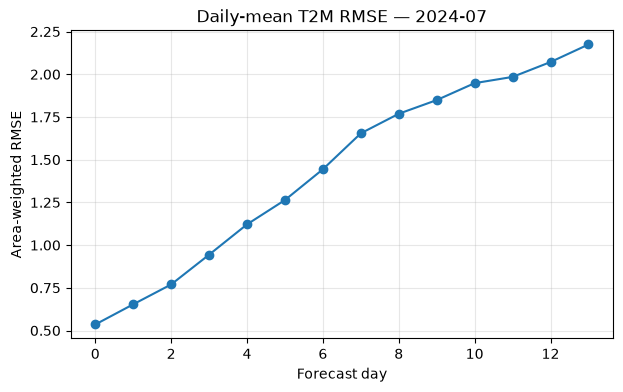

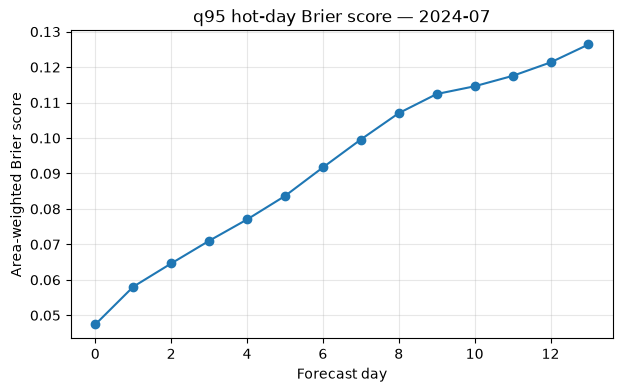

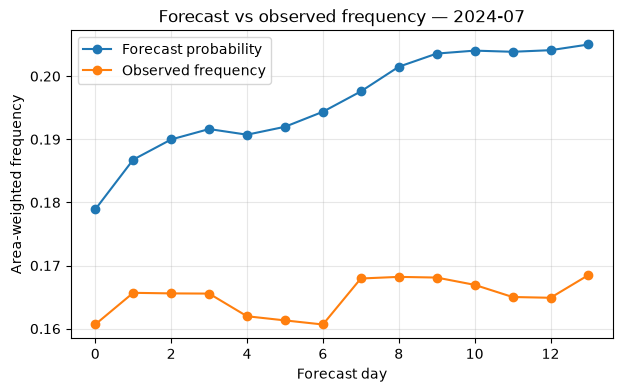

In [13]:
for column,ylabel,title,filename in [
    ('temperature_rmse','Area-weighted RMSE','Daily-mean T2M RMSE','rmse'),
    ('hot_day_brier_score','Area-weighted Brier score','q95 hot-day Brier score','brier')]:
    fig,ax=plt.subplots(figsize=(7,4)); ax.plot(lead_df.forecast_day,lead_df[column],marker='o'); ax.set(xlabel='Forecast day',ylabel=ylabel,title=f'{title} — {YEAR}-{MONTH:02d}'); ax.grid(alpha=.3); fig.savefig(FIGURE_DIR/f'{filename}_{YEAR}{MONTH:02d}.png',dpi=180,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(lead_df.forecast_day,lead_df.mean_hot_day_probability,marker='o',label='Forecast probability'); ax.plot(lead_df.forecast_day,lead_df.observed_hot_day_frequency,marker='o',label='Observed frequency'); ax.set(xlabel='Forecast day',ylabel='Area-weighted frequency',title=f'Forecast vs observed frequency — {YEAR}-{MONTH:02d}'); ax.grid(alpha=.3); ax.legend(); plt.show()

## 7. Optional inventory of all monthly stores

In [14]:
stores=sorted(AIFS_MONTHLY_ROOT.glob('20??/aifs_ens_v2_heat_20????.zarr'))
print('Stores found:',len(stores))
for p in stores[:5]: print(p)

Stores found: 48
/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202201.zarr
/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202202.zarr
/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202203.zarr
/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202204.zarr
/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202205.zarr


### Interpretation checklist

- Valid dates advance by one day at every longitude.
- Temperature maps are physically recognizable.
- Probabilities are in [0,1] and spatially coherent.
- ERA5 event maps refer to the same local valid dates.
- RMSE and Brier score generally worsen with lead.
- Mean forecast probability and observed frequency are of comparable order.